In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os
import json
import random
import shutil
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    cohen_kappa_score,
    mean_absolute_error
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

CLASS_NAMES = [f"type_{i}" for i in range(1, 7)]
CLASS_TO_LABEL = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}
LABEL_TO_CLASS = {idx: class_name for class_name, idx in CLASS_TO_LABEL.items()}

NUM_CLASSES = 6
IMG_SIZE = 224
BATCH_SIZE = 16

mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))
print("Mixed precision:", mixed_precision.global_policy())
print("CLASS_TO_LABEL:", CLASS_TO_LABEL)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: <DTypePolicy "mixed_float16">
CLASS_TO_LABEL: {'type_1': 0, 'type_2': 1, 'type_3': 2, 'type_4': 3, 'type_5': 4, 'type_6': 5}


In [ ]:
DRIVE_ROOT = Path("/content/drive/MyDrive/SYNAR")
PIPELINE_V3_DIR = DRIVE_ROOT / "pipeline_v3"

# Input dari Notebook 05
FEATURE_DIR = PIPELINE_V3_DIR / "skin_color_features"
FEATURE_MANIFEST_PATH = FEATURE_DIR / "feature_manifest.csv"
COLOR_FEATURES_PATH = FEATURE_DIR / "color_features.csv"

BOUNDARY_FEATURE_MANIFEST_PATH = FEATURE_DIR / "boundary_feature_manifest.csv"
BOUNDARY_COLOR_FEATURES_PATH = FEATURE_DIR / "boundary_color_features.csv"

# Input image dari Notebook 04
RETINAFACE_DIR = PIPELINE_V3_DIR / "retinaface_facecrop"
ALIGNED_FACE_DIR = RETINAFACE_DIR / "aligned_faces"

# Output Notebook 06
OUTPUT_DIR = PIPELINE_V3_DIR / "model_effnetb3_hybrid"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = OUTPUT_DIR / "best_effnetb3_hybrid.keras"
FINAL_MODEL_PATH = OUTPUT_DIR / "final_effnetb3_hybrid.keras"
HISTORY_STAGE1_PATH = OUTPUT_DIR / "training_history_stage1.csv"
HISTORY_STAGE2_PATH = OUTPUT_DIR / "training_history_stage2.csv"
HISTORY_ALL_PATH = OUTPUT_DIR / "training_history_all.csv"

FEATURE_SCALER_PATH = OUTPUT_DIR / "feature_scaler.json"
METRICS_PATH = OUTPUT_DIR / "metrics_summary.json"
PREDICTION_PATH = OUTPUT_DIR / "test_predictions.csv"
VAL_PREDICTION_PATH = OUTPUT_DIR / "val_predictions.csv"
TRAIN_PREDICTION_PATH = OUTPUT_DIR / "train_predictions_for_hardmining.csv"
REPORT_PATH = OUTPUT_DIR / "classification_report.txt"
CONFUSION_MATRIX_PATH = OUTPUT_DIR / "confusion_matrix.csv"
CONFIG_PATH = OUTPUT_DIR / "training_config.json"

BOUNDARY_PREDICTION_PATH = OUTPUT_DIR / "boundary_predictions.csv"

print("FEATURE_MANIFEST_PATH:", FEATURE_MANIFEST_PATH)
print("ALIGNED_FACE_DIR:", ALIGNED_FACE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

assert FEATURE_MANIFEST_PATH.exists(), f"feature_manifest.csv tidak ditemukan: {FEATURE_MANIFEST_PATH}"
assert ALIGNED_FACE_DIR.exists(), f"aligned_faces tidak ditemukan: {ALIGNED_FACE_DIR}"

FEATURE_MANIFEST_PATH: /content/drive/MyDrive/SYNAR/pipeline_v3/skin_color_features/feature_manifest.csv
ALIGNED_FACE_DIR: /content/drive/MyDrive/SYNAR/pipeline_v3/retinaface_facecrop/aligned_faces
OUTPUT_DIR: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid


#Cell 4. Konfigurasi training

In [ ]:
# Training stage 1: EfficientNet frozen
EPOCHS_STAGE1 = 15
LR_STAGE1 = 1e-3

# Training stage 2: fine-tuning sebagian EfficientNet
EPOCHS_STAGE2 = 20
LR_STAGE2 = 1e-5

# Fine-tune last N layers, tetapi BatchNorm tetap frozen
FINE_TUNE_LAST_N_LAYERS = 80

# Loss setting
FOCAL_GAMMA = 2.0
ORDINAL_LAMBDA = 0.15

# Regularisasi
DROPOUT_IMAGE = 0.40
DROPOUT_COLOR = 0.25
DROPOUT_FUSION_1 = 0.45
DROPOUT_FUSION_2 = 0.35
L2_REG = 1e-4

# Dataset
AUTOTUNE = tf.data.AUTOTUNE

print("EPOCHS_STAGE1:", EPOCHS_STAGE1)
print("EPOCHS_STAGE2:", EPOCHS_STAGE2)
print("BATCH_SIZE:", BATCH_SIZE)
print("LR_STAGE1:", LR_STAGE1)
print("LR_STAGE2:", LR_STAGE2)

EPOCHS_STAGE1: 15
EPOCHS_STAGE2: 20
BATCH_SIZE: 16
LR_STAGE1: 0.001
LR_STAGE2: 1e-05


#Cell 5. Load feature manifest

In [ ]:
df = pd.read_csv(FEATURE_MANIFEST_PATH)

print("Total rows:", len(df))
print("Columns:", df.columns.tolist())

required_cols = [
    "drive_aligned_path",
    "class_name",
    "label",
    "split",
    "v3_row_id",
    "image_uid",
    "feature_status"
]

missing_cols = [c for c in required_cols if c not in df.columns]
assert len(missing_cols) == 0, f"Kolom feature_manifest kurang: {missing_cols}"

df = df[df["feature_status"] == "ok"].copy()
df = df.reset_index(drop=True)

print("Rows feature_status ok:", len(df))

display(df.head())

display(
    df.groupby(["split", "class_name"])
    .size()
    .reset_index(name="count")
)

Total rows: 3833
Columns: ['path', 'filename', 'stem', 'class_name', 'label', 'split', 'subject_id', 'v3_row_id', 'image_uid', 'original_class_name', 'original_label', 'original_split', 'final_class_name', 'final_label', 'v3_dataset_status', 'v3_manual_decision', 'v3_decision_source', 'label_changed', 'source_image_path', 'source_path_column', 'source_path_exists', 'drive_aligned_path', 'local_aligned_path', 'skin_mask_path', 'skin_preview_path', 'normalized_face_path', 'status', 'mask_status', 'skin_pixel_ratio', 'ratio_ycrcb', 'ratio_hsv', 'ratio_lab', 'valid_region_ratio', 'rgb_r_mean', 'rgb_r_std', 'rgb_r_median', 'rgb_r_p10', 'rgb_r_p25', 'rgb_r_p75', 'rgb_r_p90', 'rgb_g_mean', 'rgb_g_std', 'rgb_g_median', 'rgb_g_p10', 'rgb_g_p25', 'rgb_g_p75', 'rgb_g_p90', 'rgb_b_mean', 'rgb_b_std', 'rgb_b_median', 'rgb_b_p10', 'rgb_b_p25', 'rgb_b_p75', 'rgb_b_p90', 'lab_l_mean', 'lab_l_std', 'lab_l_median', 'lab_l_p10', 'lab_l_p25', 'lab_l_p75', 'lab_l_p90', 'lab_a_mean', 'lab_a_std', 'lab_a_med

,path,filename,stem,class_name,label,split,subject_id,v3_row_id,image_uid,original_class_name,...,ita_max,image_mean_brightness,image_std_brightness,image_min_brightness,image_max_brightness,total_pixel_count,segmentation_status,dataset_kind,feature_status,drive_skin_preview_path
0,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,dataset_synar_part5_ready_224_4689_4689_tagalo...,dataset_synar_part5_ready_224_4689_4689_tagalo...,type_4,3,train,dataset_synar_part5_ready_224_4689_4689_tagalo...,1517,train/type_4/dataset_synar_part5_ready_224_468...,type_4,...,90.0,140.012596,63.474067,25.0,248.0,50176,ok,clean,ok,/content/drive/MyDrive/SYNAR/pipeline_v3/skin_...
1,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,Copy of Screenshot 2026-05-12 034254.png,Copy of Screenshot 2026-05-12 034254__v3id778,type_4,3,train,Copy of Screenshot 2026-05-12 034254,778,train/type_4/Copy of Screenshot 2026-05-12 034...,type_4,...,90.0,102.534917,34.810889,21.0,205.0,50176,ok,clean,ok,/content/drive/MyDrive/SYNAR/pipeline_v3/skin_...
2,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,Copy of Screenshot 2026-05-16 151903.png,Copy of Screenshot 2026-05-16 151903__v3id1356,type_6,5,train,Copy of Screenshot 2026-05-16 151903,1356,train/type_6/Copy of Screenshot 2026-05-16 151...,type_6,...,90.0,129.295759,35.422204,15.0,220.0,50176,ok,clean,ok,/content/drive/MyDrive/SYNAR/pipeline_v3/skin_...
3,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,dataset_synar_part3_ready_224_3316_3316_hindi_...,dataset_synar_part3_ready_224_3316_3316_hindi_...,type_5,4,train,dataset_synar_part3_ready_224_3316_3316_hindi_...,3204,train/type_5/dataset_synar_part3_ready_224_331...,type_5,...,90.0,104.100765,50.207039,3.0,250.0,50176,ok,clean,ok,/content/drive/MyDrive/SYNAR/pipeline_v3/skin_...
4,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,dataset_synar_part2_ready_224_2172_2172_hindi_...,dataset_synar_part2_ready_224_2172_2172_hindi_...,type_5,4,train,dataset_synar_part2_ready_224_2172_2172_hindi_...,2286,train/type_5/dataset_synar_part2_ready_224_217...,type_5,...,90.0,96.271445,56.738416,1.0,251.0,50176,ok,clean,ok,/content/drive/MyDrive/SYNAR/pipeline_v3/skin_...


,split,class_name,count
0,test,type_1,69
1,test,type_2,61
2,test,type_3,66
3,test,type_4,61
4,test,type_5,59
5,test,type_6,68
6,train,type_1,551
7,train,type_2,485
8,train,type_3,531
9,train,type_4,485


#Cell 6. Validasi path image

In [ ]:
def resolve_image_path(row):
    candidate_cols = [
        "drive_aligned_path",
        "aligned_path",
        "input_image_path",
        "path"
    ]

    for col in candidate_cols:
        if col in row.index:
            p = str(row[col])
            if p and p != "nan" and Path(p).exists():
                return p

    for col in candidate_cols:
        if col in row.index:
            p = str(row[col])
            if p and p != "nan":
                return p

    return ""


df["local_image_path"] = df.apply(resolve_image_path, axis=1)
df["image_exists"] = df["local_image_path"].apply(lambda x: Path(str(x)).exists())

display(df["image_exists"].value_counts())

missing_img_df = df[df["image_exists"] == False]

print("Missing images:", len(missing_img_df))

if len(missing_img_df) > 0:
    display(missing_img_df[["local_image_path", "drive_aligned_path", "split", "class_name"]].head(30))

assert len(missing_img_df) == 0, "Ada image yang tidak ditemukan."

,count
image_exists,
True,3833


Missing images: 0


#Cell 7. Pilih fitur warna untuk branch tabular

In [ ]:
candidate_color_feature_cols = [
    "lab_l_mean",
    "lab_l_median",
    "lab_l_std",
    "lab_a_mean",
    "lab_a_median",
    "lab_b_mean",
    "lab_b_median",
    "hsv_h_mean",
    "hsv_s_mean",
    "hsv_v_mean",
    "ita_mean",
    "ita_median",
    "ita_p25",
    "ita_p75",
    "skin_pixel_ratio",
    "image_mean_brightness",
    "image_std_brightness"
]

color_feature_cols = [
    col for col in candidate_color_feature_cols
    if col in df.columns
]

print("Jumlah color features:", len(color_feature_cols))
print(color_feature_cols)

assert len(color_feature_cols) >= 8, "Fitur warna terlalu sedikit. Cek output Notebook 05."

print("\nNaN check sebelum scaling:")
for col in color_feature_cols:
    print(col, "NaN:", df[col].isna().sum())

Jumlah color features: 17
['lab_l_mean', 'lab_l_median', 'lab_l_std', 'lab_a_mean', 'lab_a_median', 'lab_b_mean', 'lab_b_median', 'hsv_h_mean', 'hsv_s_mean', 'hsv_v_mean', 'ita_mean', 'ita_median', 'ita_p25', 'ita_p75', 'skin_pixel_ratio', 'image_mean_brightness', 'image_std_brightness']

NaN check sebelum scaling:
lab_l_mean NaN: 0
lab_l_median NaN: 0
lab_l_std NaN: 0
lab_a_mean NaN: 0
lab_a_median NaN: 0
lab_b_mean NaN: 0
lab_b_median NaN: 0
hsv_h_mean NaN: 0
hsv_s_mean NaN: 0
hsv_v_mean NaN: 0
ita_mean NaN: 0
ita_median NaN: 0
ita_p25 NaN: 0
ita_p75 NaN: 0
skin_pixel_ratio NaN: 0
image_mean_brightness NaN: 0
image_std_brightness NaN: 0


#Cell 8. Split dataframe train, val, test

In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

display(train_df["class_name"].value_counts().sort_index())
display(val_df["class_name"].value_counts().sort_index())
display(test_df["class_name"].value_counts().sort_index())

assert len(train_df) > 0, "Train kosong."
assert len(val_df) > 0, "Val kosong."
assert len(test_df) > 0, "Test kosong."

Train: 3065
Val: 384
Test: 384


,count
class_name,
type_1,551
type_2,485
type_3,531
type_4,485
type_5,470
type_6,543


,count
class_name,
type_1,69
type_2,61
type_3,66
type_4,61
type_5,59
type_6,68


,count
class_name,
type_1,69
type_2,61
type_3,66
type_4,61
type_5,59
type_6,68


#Cell 9. Standardisasi fitur warna berdasarkan train set

In [ ]:
feature_median = train_df[color_feature_cols].median()
feature_mean = train_df[color_feature_cols].mean()
feature_std = train_df[color_feature_cols].std().replace(0, 1.0)

def apply_feature_scaling(dataframe):
    temp = dataframe.copy()

    for col in color_feature_cols:
        temp[col] = temp[col].fillna(feature_median[col])
        temp[col] = (temp[col] - feature_mean[col]) / feature_std[col]

    return temp


train_df = apply_feature_scaling(train_df)
val_df = apply_feature_scaling(val_df)
test_df = apply_feature_scaling(test_df)

scaler_info = {
    "created_at": datetime.now().isoformat(),
    "color_feature_cols": color_feature_cols,
    "median": feature_median.to_dict(),
    "mean": feature_mean.to_dict(),
    "std": feature_std.to_dict()
}

with open(FEATURE_SCALER_PATH, "w", encoding="utf-8") as f:
    json.dump(scaler_info, f, indent=2)

print("Scaler saved:", FEATURE_SCALER_PATH)

display(train_df[color_feature_cols].describe().T.head(20))

Scaler saved: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/feature_scaler.json


,count,mean,std,min,25%,50%,75%,max
lab_l_mean,3065.0,1.312707e-16,1.0,-4.768177,-0.616716,0.025833,0.656870,3.347236
lab_l_median,3065.0,-1.738685e-16,1.0,-4.310159,-0.643525,0.049061,0.700907,3.267551
lab_l_std,3065.0,2.608028e-16,1.0,-4.336688,-0.646864,0.028612,0.700055,3.708586
lab_a_mean,3065.0,1.889371e-16,1.0,-4.278573,-0.657286,-0.120810,0.472046,5.227819
lab_a_median,3065.0,1.008437e-16,1.0,-4.266788,-0.696944,-0.066971,0.563002,4.342837
lab_b_mean,3065.0,3.187590e-17,1.0,-4.369607,-0.678076,-0.026512,0.617360,4.795891
lab_b_median,3065.0,1.066394e-16,1.0,-4.311205,-0.620679,-0.117426,0.553579,6.257118
hsv_h_mean,3065.0,-5.447881e-17,1.0,-1.208711,-0.681635,-0.354032,0.363720,5.150851
hsv_s_mean,3065.0,-2.011079e-16,1.0,-3.246125,-0.751506,-0.060893,0.642630,3.620806
hsv_v_mean,3065.0,1.611182e-16,1.0,-5.339707,-0.606202,0.088502,0.689274,3.305211


#Cell 10. Hitung class weight dan sample weight

In [ ]:
train_counts = train_df["label"].value_counts().sort_index()

class_weights = {}
n_train = len(train_df)

for label_idx in range(NUM_CLASSES):
    count = train_counts.get(label_idx, 0)
    class_weights[label_idx] = n_train / (NUM_CLASSES * count)

print("Class weights:")
print(class_weights)

train_df["sample_weight"] = train_df["label"].map(class_weights).astype("float32")
val_df["sample_weight"] = 1.0
test_df["sample_weight"] = 1.0

display(train_df[["class_name", "label", "sample_weight"]].head())
display(train_df["sample_weight"].describe())

Class weights:
{0: np.float64(0.927102238354507), 1: np.float64(1.0532646048109966), 2: np.float64(0.9620213433772756), 3: np.float64(1.0532646048109966), 4: np.float64(1.0868794326241136), 5: np.float64(0.9407612031921424)}


,class_name,label,sample_weight
0,type_4,3,1.053265
1,type_4,3,1.053265
2,type_6,5,0.940761
3,type_5,4,1.086879
4,type_5,4,1.086879


,sample_weight
count,3065.000000
mean,1.000000
std,0.062318
min,0.927102
25%,0.940761
50%,0.962021
75%,1.053265
max,1.086879


#Cell 11. Buat tf.data dataset

In [ ]:
def load_train_item(path, color_features, label, sample_weight):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(
        img_bytes,
        channels=3,
        expand_animations=False
    )

    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)

    color_features = tf.cast(color_features, tf.float32)
    label = tf.cast(label, tf.int32)
    sample_weight = tf.cast(sample_weight, tf.float32)

    inputs = {
        "image_input": img,
        "color_input": color_features
    }

    return inputs, label, sample_weight


def load_predict_item(path, color_features, label):
    img_bytes = tf.io.read_file(path)
    img = tf.io.decode_image(
        img_bytes,
        channels=3,
        expand_animations=False
    )

    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)

    color_features = tf.cast(color_features, tf.float32)
    label = tf.cast(label, tf.int32)

    inputs = {
        "image_input": img,
        "color_input": color_features
    }

    return inputs, label


def make_train_dataset(dataframe, shuffle=True):
    paths = dataframe["local_image_path"].values.astype(str)
    features = dataframe[color_feature_cols].values.astype("float32")
    labels = dataframe["label"].values.astype("int32")
    sample_weights = dataframe["sample_weight"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, features, labels, sample_weights)
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_train_item, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


def make_eval_dataset(dataframe):
    paths = dataframe["local_image_path"].values.astype(str)
    features = dataframe[color_feature_cols].values.astype("float32")
    labels = dataframe["label"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices(
        (paths, features, labels)
    )

    ds = ds.map(load_predict_item, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_train_dataset(train_df, shuffle=True)
val_ds = make_eval_dataset(val_df)
test_ds = make_eval_dataset(test_df)

print("Dataset siap.")

Dataset siap.


#Cell 12. Cek batch dataset

In [ ]:
for batch in train_ds.take(1):
    inputs, labels, weights = batch

    print("Image batch:", inputs["image_input"].shape)
    print("Color batch:", inputs["color_input"].shape)
    print("Label batch:", labels.shape)
    print("Weight batch:", weights.shape)
    print("Image min/max:", tf.reduce_min(inputs["image_input"]).numpy(), tf.reduce_max(inputs["image_input"]).numpy())
    print("Color sample:", inputs["color_input"][0].numpy())
    print("Labels:", labels[:10].numpy())
    print("Weights:", weights[:10].numpy())

Image batch: (16, 224, 224, 3)
Color batch: (16, 17)
Label batch: (16,)
Weight batch: (16,)
Image min/max: 0.0 255.0
Color sample: [ 0.28784057 -0.0324195  -1.288462   -0.52153057 -0.06697099 -0.00240564
  0.05032535 -0.5326239  -0.4555261   0.04141062  0.42964816  0.04764653
  0.6126109   0.5306898   0.5344434  -0.12910846 -0.564426  ]
Labels: [5 0 0 1 3 1 4 1 5 5]
Weights: [0.9407612  0.92710227 0.92710227 1.0532646  1.0532646  1.0532646
 1.0868795  1.0532646  0.9407612  0.9407612 ]


#Cell 13. Custom metric dan loss ordinal focal

In [ ]:
@tf.keras.utils.register_keras_serializable(package="Synar")
class OrdinalMAE(tf.keras.metrics.Metric):
    def __init__(self, name="ordinal_mae", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total = self.add_weight(name="total", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred_label = tf.cast(tf.argmax(y_pred, axis=-1), tf.float32)

        error = tf.abs(y_pred_label - y_true)

        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, tf.float32)
            error = error * sample_weight
            batch_count = tf.reduce_sum(sample_weight)
        else:
            batch_count = tf.cast(tf.size(error), tf.float32)

        self.total.assign_add(tf.reduce_sum(error))
        self.count.assign_add(batch_count)

    def result(self):
        return tf.math.divide_no_nan(self.total, self.count)

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)


@tf.keras.utils.register_keras_serializable(package="Synar")
class OrdinalFocalLoss(tf.keras.losses.Loss):
    def __init__(
        self,
        num_classes=6,
        gamma=2.0,
        ordinal_lambda=0.15,
        name="ordinal_focal_loss",
        **kwargs
    ):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.gamma = gamma
        self.ordinal_lambda = ordinal_lambda

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)

        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

        y_true_onehot = tf.one_hot(y_true, depth=self.num_classes)
        p_t = tf.reduce_sum(y_true_onehot * y_pred, axis=-1)

        focal_factor = tf.pow(1.0 - p_t, self.gamma)
        focal_loss = focal_factor * ce

        class_indices = tf.cast(tf.range(self.num_classes), tf.float32)
        expected_label = tf.reduce_sum(y_pred * class_indices, axis=-1)
        true_label = tf.cast(y_true, tf.float32)

        ordinal_penalty = tf.abs(expected_label - true_label) / float(self.num_classes - 1)

        return focal_loss + self.ordinal_lambda * ordinal_penalty

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_classes": self.num_classes,
            "gamma": self.gamma,
            "ordinal_lambda": self.ordinal_lambda
        })
        return config

#Cell 14. Fungsi build model EfficientNetB3 hybrid

In [ ]:
def build_effnetb3_hybrid_model(
    num_classes=6,
    feature_dim=10,
    img_size=224,
    train_base=False
):
    image_input = keras.Input(
        shape=(img_size, img_size, 3),
        name="image_input"
    )

    color_input = keras.Input(
        shape=(feature_dim,),
        name="color_input"
    )

    # Augmentasi ringan. Hindari augmentasi warna ekstrem karena target berkaitan dengan skin tone.
    x = layers.RandomFlip("horizontal", name="aug_flip")(image_input)
    x = layers.RandomRotation(0.03, name="aug_rotation")(x)
    x = layers.RandomZoom(0.05, name="aug_zoom")(x)
    x = layers.RandomTranslation(0.03, 0.03, name="aug_translation")(x)

    base_model = keras.applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3)
    )

    base_model.trainable = train_base

    image_features = base_model(x, training=False)

    image_features = layers.GlobalAveragePooling2D(name="image_gap")(image_features)
    image_features = layers.BatchNormalization(name="image_bn")(image_features)
    image_features = layers.Dropout(DROPOUT_IMAGE, name="image_dropout")(image_features)

    image_features = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name="image_dense"
    )(image_features)

    image_features = layers.BatchNormalization(name="image_dense_bn")(image_features)

    # Color feature branch
    c = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name="color_dense_1"
    )(color_input)

    c = layers.BatchNormalization(name="color_bn_1")(c)
    c = layers.Dropout(DROPOUT_COLOR, name="color_dropout_1")(c)

    c = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name="color_dense_2"
    )(c)

    # Fusion
    fusion = layers.Concatenate(name="fusion_concat")([
        image_features,
        c
    ])

    fusion = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name="fusion_dense_1"
    )(fusion)

    fusion = layers.BatchNormalization(name="fusion_bn_1")(fusion)
    fusion = layers.Dropout(DROPOUT_FUSION_1, name="fusion_dropout_1")(fusion)

    fusion = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(L2_REG),
        name="fusion_dense_2"
    )(fusion)

    fusion = layers.BatchNormalization(name="fusion_bn_2")(fusion)
    fusion = layers.Dropout(DROPOUT_FUSION_2, name="fusion_dropout_2")(fusion)

    output = layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="skin_type_output"
    )(fusion)

    model = keras.Model(
        inputs={
            "image_input": image_input,
            "color_input": color_input
        },
        outputs=output,
        name="synar_v3_effnetb3_hybrid"
    )

    return model, base_model


model, base_model = build_effnetb3_hybrid_model(
    num_classes=NUM_CLASSES,
    feature_dim=len(color_feature_cols),
    img_size=IMG_SIZE,
    train_base=False
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "synar_v3_effnetb3_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aug_flip            │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aug_rotation        │ (None, 224, 224,  │          0 │ aug_flip[0][0]    │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aug_zoom            │ (None, 224, 224,  │          0 │ aug_rotation[0][… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aug_translation     │ (None, 224, 224,  │          0 │ aug_zoom[0][0]    │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 7, 7,      │ 10,783,535 │ aug_translation[… │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_gap           │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_input         │ (None, 17)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_bn            │ (None, 1536)      │      6,144 │ image_gap[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_dense_1       │ (None, 64)        │      1,152 │ color_input[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dropout       │ (None, 1536)      │          0 │ image_bn[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_bn_1          │ (None, 64)        │        256 │ color_dense_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense (Dense) │ (None, 256)       │    393,472 │ image_dropout[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_dropout_1     │ (None, 64)        │          0 │ color_bn_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_dense_bn      │ (None, 256)       │      1,024 │ image_dense[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ color_dense_2       │ (None, 32)        │      2,080 │ color_dropout_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 288)       │          0 │ image_dense_bn[0… │
│ (Concatenate)       │                   │            │ color_dense_2[0]

 Total params: 11,296,853 (43.09 MB)

 Trainable params: 508,838 (1.94 MB)

 Non-trainable params: 10,788,015 (41.15 MB)

#Cell 15. Compile model stage 1

In [ ]:
loss_fn = OrdinalFocalLoss(
    num_classes=NUM_CLASSES,
    gamma=FOCAL_GAMMA,
    ordinal_lambda=ORDINAL_LAMBDA
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE1),
    loss=loss_fn,
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_accuracy"),
        OrdinalMAE(name="ordinal_mae")
    ]
)

print("Model compiled untuk stage 1.")

Model compiled untuk stage 1.


#Cell 16. Callbacks stage 1

In [ ]:
callbacks_stage1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_ordinal_mae",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_ordinal_mae",
        mode="min",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_ordinal_mae",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

#Cell 17. Training stage 1

In [ ]:
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_stage1,
    verbose=1
)

history_stage1_df = pd.DataFrame(history_stage1.history)
history_stage1_df["stage"] = "stage1_frozen_base"
history_stage1_df["epoch"] = np.arange(1, len(history_stage1_df) + 1)

history_stage1_df.to_csv(HISTORY_STAGE1_PATH, index=False)

print("Saved:", HISTORY_STAGE1_PATH)
display(history_stage1_df.tail())

Epoch 1/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3099 - loss: 1.7080 - ordinal_mae: 1.3477 - top2_accuracy: 0.5381
Epoch 1: val_ordinal_mae improved from None to 0.70573, saving model to /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/best_effnetb3_hybrid.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/best_effnetb3_hybrid.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 511s 2s/step - accuracy: 0.3657 - loss: 1.5000 - ordinal_mae: 1.1948 - top2_accuracy: 0.5993 - val_accuracy: 0.5677 - val_loss: 0.7608 - val_ordinal_mae: 0.7057 - val_top2_accuracy: 0.7969 - learning_rate: 0.0010
Epoch 2/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4486 - loss: 1.0976 - ordinal_mae: 0.9465 - top2_accuracy: 0.7070
Epoch 2: val_ordinal_mae improved from 0.70573 to 0.55208, saving model to /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/best_effnetb3_hybrid.keras

Epoch 2: finished saving model to /conten

,accuracy,loss,ordinal_mae,top2_accuracy,val_accuracy,val_loss,val_ordinal_mae,val_top2_accuracy,learning_rate,stage,epoch
10,0.624796,0.613613,0.528222,0.861664,0.666667,0.543998,0.471354,0.911458,0.00100,stage1_frozen_base,11
11,0.641762,0.609242,0.523980,0.870799,0.643229,0.553828,0.455729,0.888021,0.00100,stage1_frozen_base,12
12,0.669494,0.557206,0.471778,0.891354,0.671875,0.526945,0.445312,0.901042,0.00050,stage1_frozen_base,13
13,0.655791,0.566637,0.487113,0.882545,0.682292,0.515583,0.421875,0.919271,0.00050,stage1_frozen_base,14
14,0.673736,0.543607,0.470147,0.896574,0.687500,0.508740,0.419271,0.916667,0.00025,stage1_frozen_base,15


#Cell 18. Fine-tuning setup stage 2

In [ ]:
base_model.trainable = True

# Freeze semua layer dulu
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last N layers, kecuali BatchNorm
for layer in base_model.layers[-FINE_TUNE_LAST_N_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_count = sum([layer.trainable for layer in base_model.layers])
print("Base model layers:", len(base_model.layers))
print("Trainable base layers:", trainable_count)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss=loss_fn,
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name="top2_accuracy"),
        OrdinalMAE(name="ordinal_mae")
    ]
)

print("Model compiled untuk stage 2 fine-tuning.")

Base model layers: 385
Trainable base layers: 63
Model compiled untuk stage 2 fine-tuning.


#Cell 19. Callbacks stage 2

In [ ]:
callbacks_stage2 = [
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_ordinal_mae",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_ordinal_mae",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_ordinal_mae",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

#Cell 20. Training stage 2

In [ ]:
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2,
    verbose=1
)

history_stage2_df = pd.DataFrame(history_stage2.history)
history_stage2_df["stage"] = "stage2_finetune"
history_stage2_df["epoch"] = np.arange(1, len(history_stage2_df) + 1)

history_stage2_df.to_csv(HISTORY_STAGE2_PATH, index=False)

history_all_df = pd.concat([history_stage1_df, history_stage2_df], ignore_index=True)
history_all_df.to_csv(HISTORY_ALL_PATH, index=False)

print("Saved:")
print(HISTORY_STAGE2_PATH)
print(HISTORY_ALL_PATH)

display(history_stage2_df.tail())

Epoch 1/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7012 - loss: 0.5217 - ordinal_mae: 0.4106 - top2_accuracy: 0.9084
Epoch 1: val_ordinal_mae improved from None to 0.40104, saving model to /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/best_effnetb3_hybrid.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/best_effnetb3_hybrid.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 85s 228ms/step - accuracy: 0.7021 - loss: 0.5156 - ordinal_mae: 0.4069 - top2_accuracy: 0.9073 - val_accuracy: 0.6953 - val_loss: 0.4991 - val_ordinal_mae: 0.4010 - val_top2_accuracy: 0.9089 - learning_rate: 1.0000e-05
Epoch 2/20
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7173 - loss: 0.4908 - ordinal_mae: 0.3946 - top2_accuracy: 0.9093
Epoch 2: val_ordinal_mae improved from 0.40104 to 0.39583, saving model to /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/best_effnetb3_hybrid.keras

Epoch 2: finished saving model 

,accuracy,loss,ordinal_mae,top2_accuracy,val_accuracy,val_loss,val_ordinal_mae,val_top2_accuracy,learning_rate,stage,epoch
15,0.760522,0.400148,0.301142,0.947798,0.723958,0.431129,0.328125,0.932292,0.000005,stage2_finetune,16
16,0.759217,0.407562,0.302447,0.943883,0.721354,0.434464,0.328125,0.929688,0.000005,stage2_finetune,17
17,0.744209,0.420633,0.326264,0.942904,0.723958,0.432533,0.320312,0.927083,0.000005,stage2_finetune,18
18,0.737031,0.422101,0.333442,0.938989,0.726562,0.433763,0.320312,0.932292,0.000005,stage2_finetune,19
19,0.763458,0.385300,0.277977,0.949103,0.710938,0.432935,0.346354,0.927083,0.000005,stage2_finetune,20


#Cell 21. Load best model

In [ ]:
custom_objects = {
    "OrdinalFocalLoss": OrdinalFocalLoss,
    "OrdinalMAE": OrdinalMAE
}

best_model = keras.models.load_model(
    CHECKPOINT_PATH,
    custom_objects=custom_objects
)

print("Best model loaded:", CHECKPOINT_PATH)

Best model loaded: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/best_effnetb3_hybrid.keras


#Cell 22. Evaluasi Keras pada test set

In [ ]:
test_eval = best_model.evaluate(test_ds, verbose=1)

print("Test evaluation:")
for name, value in zip(best_model.metrics_names, test_eval):
    print(name, ":", value)

24/24 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.7344 - loss: 0.4372 - ordinal_mae: 0.3229 - top2_accuracy: 0.9193
Test evaluation:
loss : 0.4372413158416748
compile_metrics : 0.734375


#Cell 23. Fungsi prediksi dataframe

In [ ]:
def make_predict_dataset(dataframe):
    paths = dataframe["local_image_path"].values.astype(str)
    features = dataframe[color_feature_cols].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((paths, features))

    def load_item(path, color_features):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(
            img_bytes,
            channels=3,
            expand_animations=False
        )
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)

        return {
            "image_input": img,
            "color_input": tf.cast(color_features, tf.float32)
        }

    ds = ds.map(load_item, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


def predict_dataframe(dataframe, model, dataset_name="test"):
    pred_ds = make_predict_dataset(dataframe)

    probs = model.predict(pred_ds, verbose=1)
    pred_labels = np.argmax(probs, axis=1)
    true_labels = dataframe["label"].values.astype(int)

    out_df = dataframe.copy()
    out_df["true_label"] = true_labels
    out_df["true_class"] = [LABEL_TO_CLASS[i] for i in true_labels]
    out_df["pred_label"] = pred_labels
    out_df["pred_class"] = [LABEL_TO_CLASS[i] for i in pred_labels]
    out_df["pred_confidence"] = np.max(probs, axis=1)
    out_df["is_correct"] = out_df["true_label"] == out_df["pred_label"]
    out_df["ordinal_error"] = np.abs(out_df["true_label"] - out_df["pred_label"])

    sorted_probs = np.sort(probs, axis=1)
    out_df["top1_top2_margin"] = sorted_probs[:, -1] - sorted_probs[:, -2]

    top2_pred = np.argsort(probs, axis=1)[:, -2:]
    out_df["is_true_in_top2"] = [
        true_labels[i] in top2_pred[i]
        for i in range(len(true_labels))
    ]

    out_df["true_prob"] = [
        probs[i, true_labels[i]]
        for i in range(len(true_labels))
    ]

    for i, class_name in enumerate(CLASS_NAMES):
        out_df[f"prob_{class_name}"] = probs[:, i]

    out_df["prediction_dataset"] = dataset_name

    return out_df, probs

#Cell 24. Prediksi train, val, dan test

In [ ]:
train_pred_df, train_probs = predict_dataframe(
    train_df,
    best_model,
    dataset_name="train"
)

val_pred_df, val_probs = predict_dataframe(
    val_df,
    best_model,
    dataset_name="val"
)

test_pred_df, test_probs = predict_dataframe(
    test_df,
    best_model,
    dataset_name="test"
)

train_pred_df.to_csv(TRAIN_PREDICTION_PATH, index=False)
val_pred_df.to_csv(VAL_PREDICTION_PATH, index=False)
test_pred_df.to_csv(PREDICTION_PATH, index=False)

print("Saved:")
print(TRAIN_PREDICTION_PATH)
print(VAL_PREDICTION_PATH)
print(PREDICTION_PATH)

display(test_pred_df.head())

192/192 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
Saved:
/content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/train_predictions_for_hardmining.csv
/content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/val_predictions.csv
/content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/test_predictions.csv


,path,filename,stem,class_name,label,split,subject_id,v3_row_id,image_uid,original_class_name,...,top1_top2_margin,is_true_in_top2,true_prob,prob_type_1,prob_type_2,prob_type_3,prob_type_4,prob_type_5,prob_type_6,prediction_dataset
0,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,0748_portuguese_scripted_0_raw_frame00001813.jpg,0748_portuguese_scripted_0_raw_frame00001813__...,type_1,0,test,0748_portuguese_scripted_0_raw,1420,train/type_1/0748_portuguese_scripted_0_raw_fr...,type_1,...,0.324921,True,0.640734,0.640734,0.315813,0.039450,0.001432,0.000529,0.002042,test
1,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,dataset_synar_part4_ready_224_4358_4358_tagalo...,dataset_synar_part4_ready_224_4358_4358_tagalo...,type_3,2,test,dataset_synar_part4_ready_224_4358_4358_tagalo...,3455,val/type_3/dataset_synar_part4_ready_224_4358_...,type_3,...,0.130329,True,0.493386,0.006265,0.034648,0.493386,0.363056,0.093552,0.009093,test
2,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,Copy of Screenshot 2026-05-16 151804.png,Copy of Screenshot 2026-05-16 151804__v3id3448,type_6,5,test,Copy of Screenshot 2026-05-16 151804,3448,val/type_6/Copy of Screenshot 2026-05-16 15180...,type_6,...,0.869808,True,0.923599,0.002342,0.003060,0.002318,0.014891,0.053791,0.923599,test
3,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,Copy of dataset_synar_part5_ready_224_5412_541...,Copy of dataset_synar_part5_ready_224_5412_541...,type_5,4,test,Copy of dataset_synar_part5_ready_224_5412_541...,2202,train/type_5/Copy of dataset_synar_part5_ready...,type_5,...,0.266619,True,0.462664,0.163227,0.062997,0.100702,0.196045,0.462664,0.014365,test
4,/content/drive/MyDrive/SYNAR/pipeline_v2/retin...,Copy of Screenshot 2026-05-12 041558.png,Copy of Screenshot 2026-05-12 041558__v3id626,type_4,3,test,Copy of Screenshot 2026-05-12 041558,626,train/type_4/Copy of Screenshot 2026-05-12 041...,type_4,...,0.174394,True,0.507115,0.018992,0.010227,0.113977,0.507115,0.332721,0.016966,test


#Cell 25. Hitung metrik evaluasi test set

In [ ]:
y_true = test_pred_df["true_label"].values.astype(int)
y_pred = test_pred_df["pred_label"].values.astype(int)

accuracy = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
kappa = cohen_kappa_score(y_true, y_pred)
ordinal_mae = mean_absolute_error(y_true, y_pred)
top2_acc = test_pred_df["is_true_in_top2"].mean()

print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_acc, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print("Cohen Kappa:", round(kappa, 4))
print("Ordinal MAE:", round(ordinal_mae, 4))
print("Top-2 Accuracy:", round(top2_acc, 4))

Accuracy: 0.7344
Balanced Accuracy: 0.7239
Macro F1: 0.7208
Weighted F1: 0.7278
Cohen Kappa: 0.6804
Ordinal MAE: 0.3229
Top-2 Accuracy: 0.9193


#Cell 26. Classification report

In [ ]:
report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print(report_text)

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved:", REPORT_PATH)

              precision    recall  f1-score   support

      type_1     0.8182    0.9130    0.8630        69
      type_2     0.8511    0.6557    0.7407        61
      type_3     0.5889    0.8030    0.6795        66
      type_4     0.5918    0.4754    0.5273        61
      type_5     0.6596    0.5254    0.5849        59
      type_6     0.8919    0.9706    0.9296        68

    accuracy                         0.7344       384
   macro avg     0.7336    0.7239    0.7208       384
weighted avg     0.7367    0.7344    0.7278       384

Saved: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/classification_report.txt


#Cell 27. Confusion matrix

,type_1,type_2,type_3,type_4,type_5,type_6
type_1,63,3,3,0,0,0
type_2,12,40,9,0,0,0
type_3,1,3,53,6,2,1
type_4,0,0,18,29,13,1
type_5,0,1,7,14,31,6
type_6,1,0,0,0,1,66


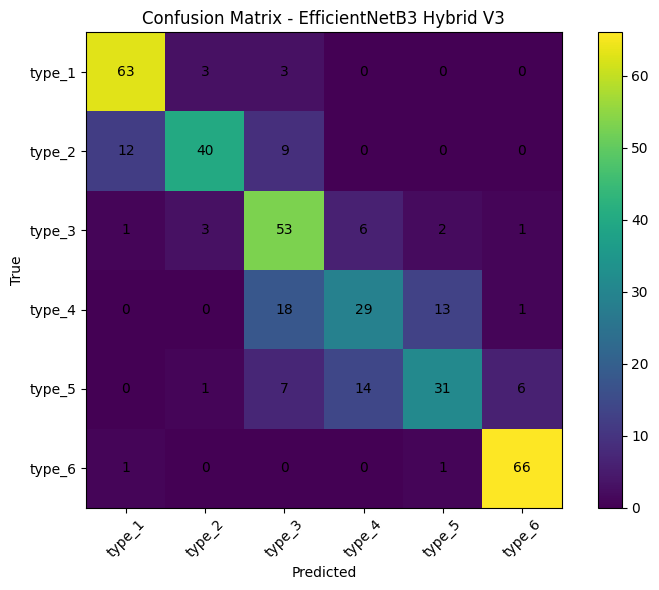

Saved: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/confusion_matrix.csv


In [ ]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

display(cm_df)

cm_df.to_csv(CONFUSION_MATRIX_PATH)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix - EfficientNetB3 Hybrid V3")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.colorbar()

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

print("Saved:", CONFUSION_MATRIX_PATH)

#Cell 28. Analisis error per kelas

In [ ]:
class_error_summary = (
    test_pred_df
    .groupby("true_class")
    .agg(
        total=("is_correct", "count"),
        correct=("is_correct", "sum"),
        accuracy=("is_correct", "mean"),
        mean_confidence=("pred_confidence", "mean"),
        mean_ordinal_error=("ordinal_error", "mean"),
        top2_accuracy=("is_true_in_top2", "mean")
    )
    .reset_index()
)

display(class_error_summary)

error_pair_summary = (
    test_pred_df[test_pred_df["is_correct"] == False]
    .groupby(["true_class", "pred_class"])
    .size()
    .reset_index(name="count")
    .sort_values(["true_class", "count"], ascending=[True, False])
)

display(error_pair_summary)

,true_class,total,correct,accuracy,mean_confidence,mean_ordinal_error,top2_accuracy
0,type_1,69,63,0.913043,0.770869,0.130435,0.942029
1,type_2,61,40,0.655738,0.536327,0.344262,0.983607
2,type_3,66,53,0.803030,0.543835,0.272727,0.924242
3,type_4,61,29,0.475410,0.512873,0.540984,0.918033
4,type_5,59,31,0.525424,0.511950,0.627119,0.728814
5,type_6,68,66,0.970588,0.827521,0.088235,1.000000


,true_class,pred_class,count
0,type_1,type_2,3
1,type_1,type_3,3
2,type_2,type_1,12
3,type_2,type_3,9
6,type_3,type_4,6
5,type_3,type_2,3
7,type_3,type_5,2
4,type_3,type_1,1
8,type_3,type_6,1
9,type_4,type_3,18


#Cell 29. Visualisasi salah prediksi

Jumlah salah prediksi: 102


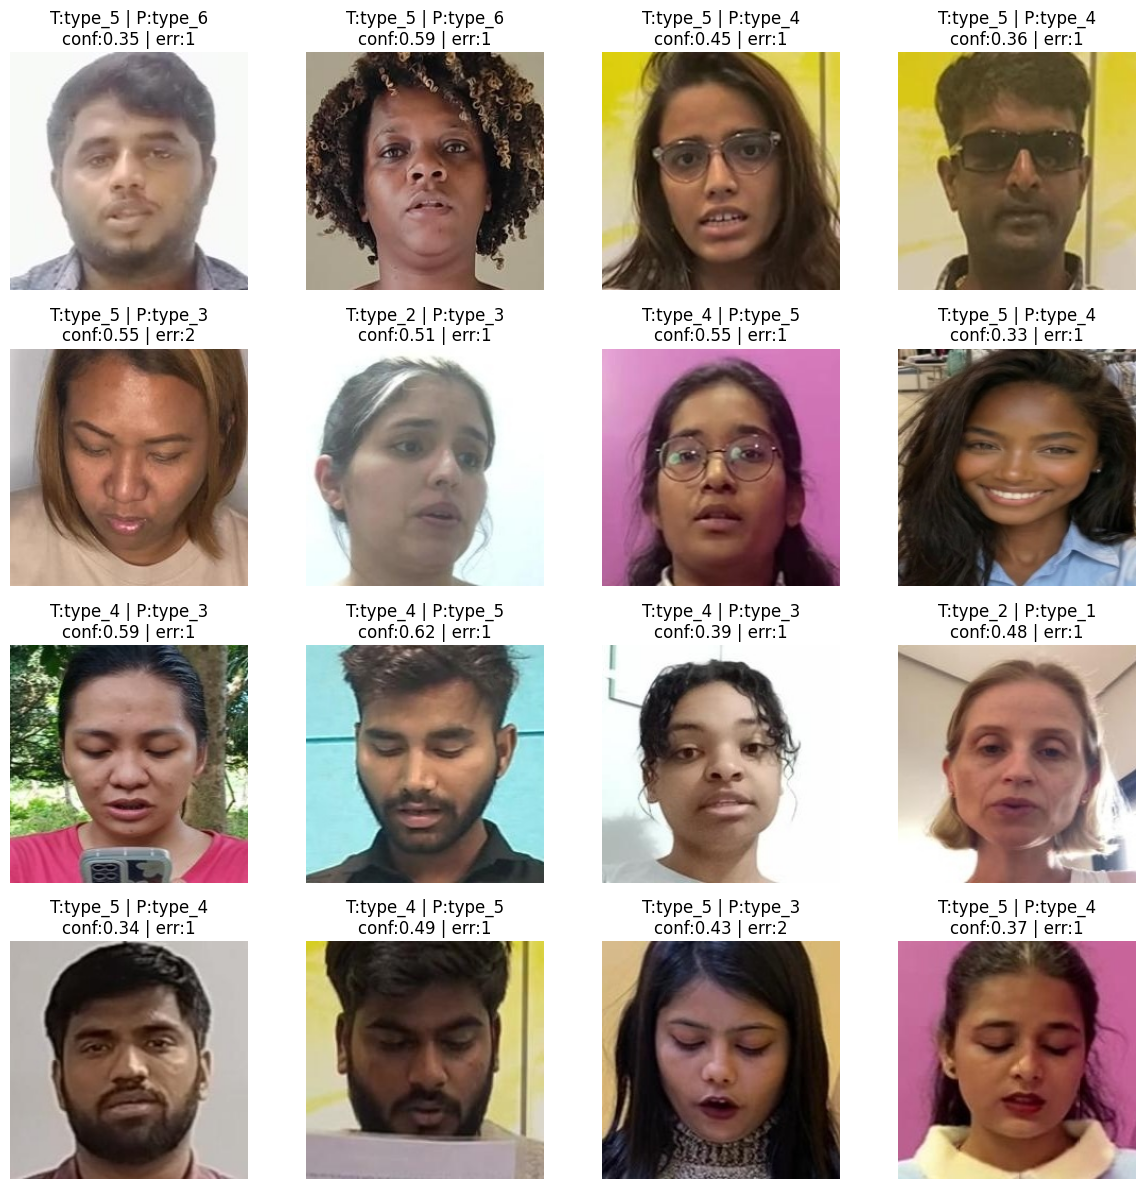

In [ ]:
wrong_df = test_pred_df[test_pred_df["is_correct"] == False].copy()

print("Jumlah salah prediksi:", len(wrong_df))

sample_n = min(16, len(wrong_df))

if sample_n > 0:
    sample_wrong = wrong_df.sample(sample_n, random_state=SEED)

    plt.figure(figsize=(12, 12))

    for i, (_, row) in enumerate(sample_wrong.iterrows()):
        img = Image.open(row["local_image_path"]).convert("RGB")

        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(img)
        plt.title(
            f"T:{row['true_class']} | P:{row['pred_class']}\n"
            f"conf:{row['pred_confidence']:.2f} | err:{row['ordinal_error']}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada salah prediksi.")

#Cell 30. Plot training history

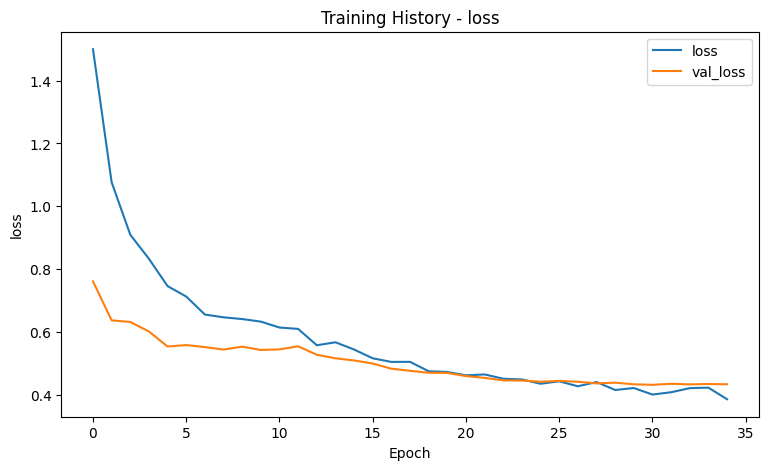

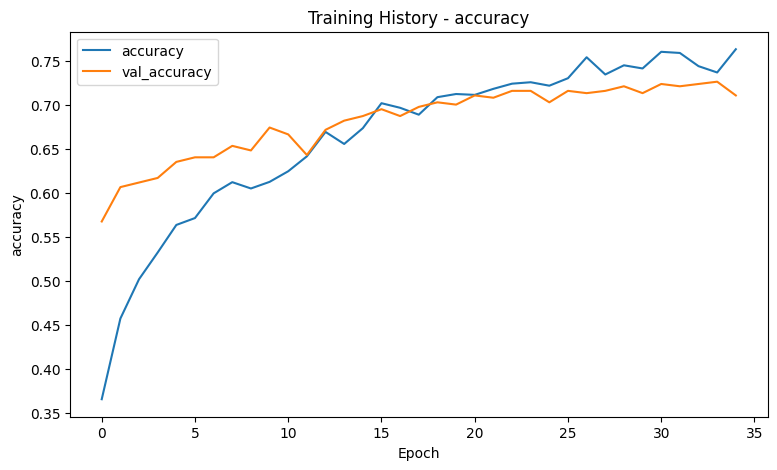

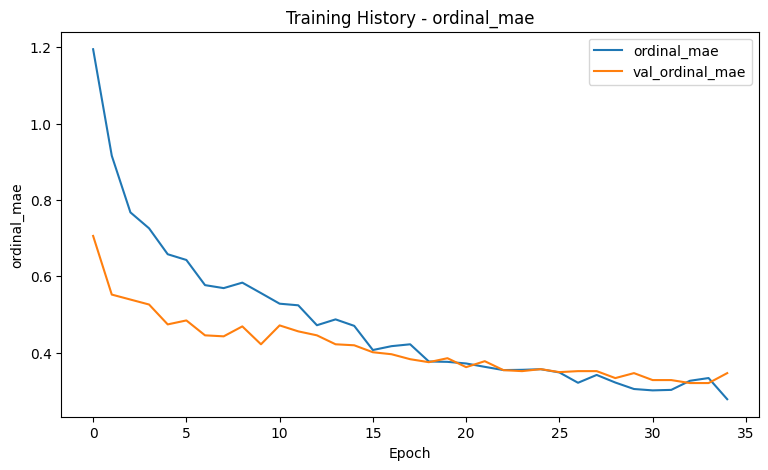

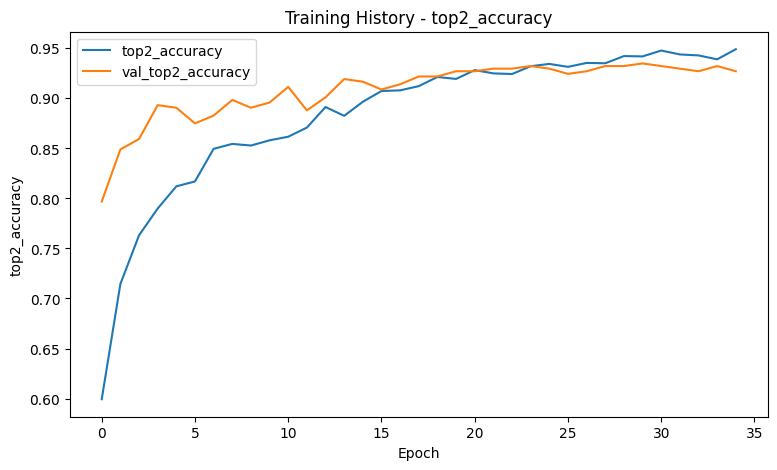

In [ ]:
if HISTORY_ALL_PATH.exists():
    hist_df = pd.read_csv(HISTORY_ALL_PATH)

    for metric in ["loss", "accuracy", "ordinal_mae", "top2_accuracy"]:
        val_metric = f"val_{metric}"

        if metric in hist_df.columns and val_metric in hist_df.columns:
            plt.figure(figsize=(9, 5))
            plt.plot(hist_df[metric].values, label=metric)
            plt.plot(hist_df[val_metric].values, label=val_metric)
            plt.title(f"Training History - {metric}")
            plt.xlabel("Epoch")
            plt.ylabel(metric)
            plt.legend()
            plt.show()
else:
    print("History file tidak ditemukan.")

#Cell 31. Simpan final model dan metrics summary

In [ ]:
best_model.save(FINAL_MODEL_PATH)

metrics_summary = {
    "created_at": datetime.now().isoformat(),
    "pipeline_name": "pipeline_v3",
    "model_name": "effnetb3_hybrid",
    "test_metrics": {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "cohen_kappa": float(kappa),
        "ordinal_mae": float(ordinal_mae),
        "top2_accuracy": float(top2_acc)
    },
    "dataset": {
        "train": int(len(train_df)),
        "val": int(len(val_df)),
        "test": int(len(test_df)),
        "num_classes": NUM_CLASSES,
        "class_names": CLASS_NAMES
    },
    "color_features": {
        "num_features": len(color_feature_cols),
        "feature_cols": color_feature_cols,
        "feature_scaler_path": str(FEATURE_SCALER_PATH)
    },
    "outputs": {
        "checkpoint": str(CHECKPOINT_PATH),
        "final_model": str(FINAL_MODEL_PATH),
        "test_predictions": str(PREDICTION_PATH),
        "val_predictions": str(VAL_PREDICTION_PATH),
        "train_predictions_for_hardmining": str(TRAIN_PREDICTION_PATH),
        "classification_report": str(REPORT_PATH),
        "confusion_matrix": str(CONFUSION_MATRIX_PATH)
    }
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2)

print("Saved final model:", FINAL_MODEL_PATH)
print("Saved metrics:", METRICS_PATH)

Saved final model: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/final_effnetb3_hybrid.keras
Saved metrics: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/metrics_summary.json


#Cell 32. Simpan training config

In [ ]:
training_config = {
    "created_at": datetime.now().isoformat(),
    "pipeline_name": "pipeline_v3",
    "notebook": "06_v3_train_effnetb3_hybrid_model",
    "input_files": {
        "feature_manifest": str(FEATURE_MANIFEST_PATH),
        "color_features": str(COLOR_FEATURES_PATH),
        "aligned_faces": str(ALIGNED_FACE_DIR)
    },
    "output_files": {
        "checkpoint": str(CHECKPOINT_PATH),
        "final_model": str(FINAL_MODEL_PATH),
        "history_stage1": str(HISTORY_STAGE1_PATH),
        "history_stage2": str(HISTORY_STAGE2_PATH),
        "history_all": str(HISTORY_ALL_PATH),
        "feature_scaler": str(FEATURE_SCALER_PATH),
        "metrics": str(METRICS_PATH),
        "test_predictions": str(PREDICTION_PATH),
        "val_predictions": str(VAL_PREDICTION_PATH),
        "train_predictions_for_hardmining": str(TRAIN_PREDICTION_PATH),
        "classification_report": str(REPORT_PATH),
        "confusion_matrix": str(CONFUSION_MATRIX_PATH)
    },
    "training_settings": {
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs_stage1": EPOCHS_STAGE1,
        "epochs_stage2": EPOCHS_STAGE2,
        "lr_stage1": LR_STAGE1,
        "lr_stage2": LR_STAGE2,
        "fine_tune_last_n_layers": FINE_TUNE_LAST_N_LAYERS,
        "focal_gamma": FOCAL_GAMMA,
        "ordinal_lambda": ORDINAL_LAMBDA,
        "dropout_image": DROPOUT_IMAGE,
        "dropout_color": DROPOUT_COLOR,
        "dropout_fusion_1": DROPOUT_FUSION_1,
        "dropout_fusion_2": DROPOUT_FUSION_2,
        "l2_reg": L2_REG,
        "mixed_precision": str(mixed_precision.global_policy())
    },
    "class_weights": {
        str(k): float(v)
        for k, v in class_weights.items()
    }
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(training_config, f, indent=2)

print("Saved:", CONFIG_PATH)

Saved: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/training_config.json


#Cell 33. evaluasi boundary challenge

In [ ]:
if BOUNDARY_FEATURE_MANIFEST_PATH.exists():
    boundary_df = pd.read_csv(BOUNDARY_FEATURE_MANIFEST_PATH)

    print("Boundary rows:", len(boundary_df))

    if len(boundary_df) > 0:
        boundary_df["local_image_path"] = boundary_df.apply(resolve_image_path, axis=1)
        boundary_df["image_exists"] = boundary_df["local_image_path"].apply(lambda x: Path(str(x)).exists())

        display(boundary_df["image_exists"].value_counts())

        boundary_df = boundary_df[boundary_df["image_exists"] == True].copy().reset_index(drop=True)

        # Apply scaler dari train
        boundary_df = apply_feature_scaling(boundary_df)

        boundary_pred_df, boundary_probs = predict_dataframe(
            boundary_df,
            best_model,
            dataset_name="boundary_challenge"
        )

        boundary_pred_df.to_csv(BOUNDARY_PREDICTION_PATH, index=False)

        print("Boundary predictions saved:", BOUNDARY_PREDICTION_PATH)

        print("\nBoundary prediction by boundary_pair and pred_class:")
        display(
            boundary_pred_df
            .groupby(["boundary_pair", "pred_class"])
            .size()
            .reset_index(name="count")
            .sort_values(["boundary_pair", "count"], ascending=[True, False])
        )

        print("\nBoundary top2 rate against original label:")
        print(boundary_pred_df["is_true_in_top2"].mean())

else:
    print("Boundary feature manifest tidak ditemukan. Lewati boundary evaluation.")

Boundary rows: 150


,count
image_exists,
True,150


10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step
Boundary predictions saved: /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/boundary_predictions.csv

Boundary prediction by boundary_pair and pred_class:


,boundary_pair,pred_class,count
2,type_1_2,type_3,8
1,type_1_2,type_2,7
0,type_1_2,type_1,1
5,type_2_3,type_3,3
3,type_2_3,type_1,1
4,type_2_3,type_2,1
8,type_3_4,type_3,14
10,type_3_4,type_5,7
9,type_3_4,type_4,6
6,type_3_4,type_1,2



Boundary top2 rate against original label:
0.6066666666666667


#Cell 34. Final checklist

In [ ]:
expected_outputs = [
    CHECKPOINT_PATH,
    FINAL_MODEL_PATH,
    HISTORY_STAGE1_PATH,
    HISTORY_STAGE2_PATH,
    HISTORY_ALL_PATH,
    FEATURE_SCALER_PATH,
    METRICS_PATH,
    PREDICTION_PATH,
    VAL_PREDICTION_PATH,
    TRAIN_PREDICTION_PATH,
    REPORT_PATH,
    CONFUSION_MATRIX_PATH,
    CONFIG_PATH
]

for path in expected_outputs:
    print(("OK" if Path(path).exists() else "MISSING"), "-", path)

print("\nNotebook 06 pipeline_v3 selesai.")

print("\nOutput utama untuk Notebook 07:")
print(FINAL_MODEL_PATH)
print(CHECKPOINT_PATH)
print(TRAIN_PREDICTION_PATH)
print(VAL_PREDICTION_PATH)
print(FEATURE_SCALER_PATH)

print("\nRingkasan performa clean test:")
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_acc, 4))
print("Macro F1:", round(macro_f1, 4))
print("Weighted F1:", round(weighted_f1, 4))
print("Cohen Kappa:", round(kappa, 4))
print("Ordinal MAE:", round(ordinal_mae, 4))
print("Top-2 Accuracy:", round(top2_acc, 4))

OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/best_effnetb3_hybrid.keras
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/final_effnetb3_hybrid.keras
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/training_history_stage1.csv
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/training_history_stage2.csv
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/training_history_all.csv
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/feature_scaler.json
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/metrics_summary.json
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/test_predictions.csv
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/val_predictions.csv
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybrid/train_predictions_for_hardmining.csv
OK - /content/drive/MyDrive/SYNAR/pipeline_v3/model_effnetb3_hybr